In [1]:
# ============================================
# Module 4: Privacy Risk & Privacy-Aware Design
# Dataset: German Credit
# Task: Evaluate privacy risks and apply privacy-preserving modifications
# ============================================

# 1. Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn requests fairlearn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import scipy.sparse
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

print('Libraries installed and imported.')

# 2. Download dataset
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
data_path = data_dir / 'german_credit_data.csv'
url = 'https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv'

if not data_path.exists():
    print('Downloading German Credit dataset...')
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(data_path, 'wb') as f:
        f.write(r.content)
    print('Download complete.')
else:
    print('Dataset already exists.')

df = pd.read_csv(data_path)
print('Dataset loaded:', df.shape)

# 3. Standardize column names
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# 4. Identify target variable
possible_targets = ['credit_risk', 'class', 'risk', 'target']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    raise ValueError(f'Could not find target column. Tried: {possible_targets}')
print('Target column:', target_col)

if df[target_col].dtype == 'object':
    cleaned = df[target_col].astype(str).str.strip().str.lower()
    if set(cleaned.unique()).issubset({'0', '1'}):
        df[target_col] = cleaned.astype(int)
    elif set(cleaned.unique()).issubset({'good', 'bad'}):
        df[target_col] = cleaned.map({'good': 1, 'bad': 0})
else:
    df[target_col] = df[target_col].astype(int)

print('Target distribution:')
print(df[target_col].value_counts())

# 5. Create protected attributes from the FULL dataset (before any feature removal)
#    These are preserved to enable fairness evaluation of BOTH the baseline and privacy models.
if 'personal_status_sex' in df.columns:
    df['sex'] = df['personal_status_sex'].apply(
        lambda x: 'female' if 'female' in str(x).lower() else 'male'
    )
if 'age' in df.columns:
    df['age_group'] = np.where(df['age'] >= 25, 'age_25_and_over', 'under_25')

print('Protected attributes created: sex, age_group')

# 6. Baseline train/test split using FULL feature set
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

# IMPORTANT: Save A_test from the BASELINE split.
# It is reused for fairness evaluation of the privacy model because
# sex/age_group are removed from the privacy dataset but are still needed as
# sensitive feature labels. The same random_state=42 + stratify guarantees
# that both splits produce identical row assignments.
protected_cols = [c for c in ['sex', 'age_group'] if c in X_train.columns]
A_train = X_train[protected_cols].copy()
A_test  = X_test[protected_cols].copy()
print('A_test preserved for cross-model fairness evaluation.')

# 7. Baseline preprocessing pipeline
numeric_features    = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)
print('Processed shapes:', X_train_processed.shape, X_test_processed.shape)
print('German Credit dataset ready for modeling.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 33.0 MB/s eta 0:00:00
Libraries installed and imported.
Download complete.
Dataset loaded: (1000, 21)
Target column: credit_risk
Target distribution:
credit_risk
1    700
0    300
Name: count, dtype: int64
Protected attributes created: sex, age_group
Train: (800, 22) | Test: (200, 22)
A_test preserved for cross-model fairness evaluation.
Processed shapes: (800, 65) (200, 65)
German Credit dataset ready for modeling.


In [2]:
# Reconstruct feature names and convert to dense matrices
num_feature_names = numeric_features
cat_feature_names = list(
    preprocessor.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
)
all_feature_names = num_feature_names + cat_feature_names
print(f'Total features after preprocessing: {len(all_feature_names)}')

X_train_dense = X_train_processed.toarray() if scipy.sparse.issparse(X_train_processed) else np.array(X_train_processed)
X_test_dense  = X_test_processed.toarray()  if scipy.sparse.issparse(X_test_processed)  else np.array(X_test_processed)
print('Dense matrices ready.')

Total features after preprocessing: 65
Dense matrices ready.


In [3]:
# ============================================
# BASELINE MODEL — Decision Tree (max_depth=5)
# Reference point for all comparisons in Parts 2 and 3
# ============================================

dt_baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_baseline.fit(X_train_dense, y_train)
y_pred_base = dt_baseline.predict(X_test_dense)

# Performance metrics
acc_base  = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base  = recall_score(y_test, y_pred_base)
f1_base   = f1_score(y_test, y_pred_base)

# Fairness metrics
dp_sex_base = demographic_parity_difference(y_test, y_pred_base, sensitive_features=A_test['sex'])
dp_age_base = demographic_parity_difference(y_test, y_pred_base, sensitive_features=A_test['age_group'])
eo_sex_base = equalized_odds_difference(y_test, y_pred_base, sensitive_features=A_test['sex'])
eo_age_base = equalized_odds_difference(y_test, y_pred_base, sensitive_features=A_test['age_group'])

# Store feature importances as a name→value dict for cross-model alignment
importances_base = {name: imp for name, imp in zip(all_feature_names, dt_baseline.feature_importances_)}

# Top 10 features
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': dt_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print('BASELINE MODEL — Decision Tree (max_depth=5)')
print('=' * 55)
print(f'  Accuracy:            {acc_base:.4f}')
print(f'  Precision:           {prec_base:.4f}')
print(f'  Recall:              {rec_base:.4f}')
print(f'  F1-Score:            {f1_base:.4f}')
print(f'  DP Diff (sex):       {dp_sex_base:.4f}')
print(f'  DP Diff (age_group): {dp_age_base:.4f}')
print(f'  EO Diff (sex):       {eo_sex_base:.4f}')
print(f'  EO Diff (age_group): {eo_age_base:.4f}')
print('=' * 55)
print(f'  Tree depth: {dt_baseline.get_depth()}  |  Leaves: {dt_baseline.get_n_leaves()}')
print(f'  Features used: {np.sum(dt_baseline.feature_importances_ > 0)} / {len(all_feature_names)}')
print()
print('Top 10 features (baseline):')
for i, row in enumerate(feat_imp_df.head(10).itertuples(), 1):
    print(f'  {i:2d}. {row.Feature:<45s} {row.Importance:.4f}')

BASELINE MODEL — Decision Tree (max_depth=5)
  Accuracy:            0.6850
  Precision:           0.7251
  Recall:              0.8857
  F1-Score:            0.7974
  DP Diff (sex):       0.1500
  DP Diff (age_group): 0.0806
  EO Diff (sex):       0.1550
  EO Diff (age_group): 0.1532
  Tree depth: 5  |  Leaves: 28
  Features used: 21 / 65

Top 10 features (baseline):
   1. status_no checking account                    0.3109
   2. duration                                      0.1760
   3. amount                                        0.1014
   4. other_debtors_guarantor                       0.0566
   5. savings_unknown/no savings account            0.0540
   6. other_installment_plans_none                  0.0386
   7. purpose_car (used)                            0.0326
   8. property_real estate                          0.0251
   9. age                                           0.0243
  10. credit_history_critical account/other credits existing 0.0241


---
# Part 1: Privacy Threat Assessment (25%)

This section evaluates the privacy risks in the German Credit ML system across the four required dimensions:
1. Sensitive attribute identification
2. Inference attack surface
3. Re-identification risk
4. Potential harms from privacy leakage

## Question 1: What are the sensitive attributes in this dataset?

The 21 raw features of the German Credit dataset fall into three privacy sensitivity tiers:

### Tier 1 — Directly Sensitive (Legally Protected)

| Feature | Sensitivity | Legal Basis |
|---|---|---|
| `personal_status_sex` | Encodes **sex AND marital status** in one compound field (e.g., "male: single", "female: divorced/separated") | Sex is protected under GDPR Article 9 and EU anti-discrimination law |
| `age` | A continuous **quasi-identifier**; combined with loan amount and duration it narrows individuals to a very small group | Age discrimination is prohibited in credit under EU directives |
| `foreign_worker` | Binary flag for **national origin** — a proxy for ethnicity and citizenship | National origin is protected under the EU Racial Equality Directive |

### Tier 2 — Indirectly Sensitive (Financial Quasi-Identifiers)

| Feature | Why Sensitive |
|---|---|
| `status` (checking account) | Reveals financial distress; correlates with socioeconomic class and, indirectly, race and gender |
| `amount` + `duration` together | Unusual loan combinations fingerprint individuals in a 1,000-record dataset |
| `housing` (own/free/rent) | Correlated with wealth and, in many countries, race via residential segregation patterns |
| `telephone` (yes/no) | In 1994 Germany (dataset era), telephone ownership was a socioeconomic status marker |

### Tier 3 — Sensitive in Aggregation

`purpose` (loan reason), `number_credits`, `people_liable` (household size) — individually benign, but combined they reveal life circumstances (medical debt, household composition) that are sensitive.

**Key finding:** The dataset contains at least 3 legally protected attributes and 4 indirect quasi-identifiers. Any deployed model must comply with GDPR data minimization requirements (Article 5(1)(c)).

## Question 2: What information could an attacker infer?

Three attack vectors are relevant to this system:

**Attack 1 — Membership Inference:**  
The German Credit dataset is publicly available. An attacker who suspects that a specific individual was evaluated can confirm membership by submitting their known attributes and checking whether the model's response matches the expected output for that record. Confirmed membership reveals that the individual applied for credit and what the outcome was — exposing financial history.

**Attack 2 — Attribute Inference via Differential Probing:**  
The model's `predict_proba` output gives a continuous score in [0, 1]. An attacker with API access can systematically toggle the `personal_status_sex` input values (male: single → female: divorced) while holding all other fields fixed. The resulting change in the probability score reveals the model's learned coefficient for sex. Similarly, probing with varying ages gives a gradient that reveals how age shifts the creditworthiness score. Module 2 confirmed that `age` carries 6% feature importance — enough to produce measurable probe responses.

**Attack 3 — Linkage Attack via Quasi-Identifiers:**  
The combination of (`age`, `duration`, `amount`, `purpose`, `foreign_worker`) creates near-unique fingerprints. In a 1,000-record dataset, the joint distribution of these fields likely has many cells with only 1–3 individuals. If an adversary has any auxiliary dataset (a public loan registry, credit bureau export, or even a news article about a loan), they can link back to real identities. The code cell below quantifies this risk.

RE-IDENTIFICATION RISK ANALYSIS
Total records: 1000

4-field QI set ['age', 'amount', 'duration', 'purpose']:
  Unique records (group size=1): 1000 / 1000 (100.0%)
  Average group size: 1.00

5-field QI set ['age', 'amount', 'duration', 'purpose', 'foreign_worker']:
  Unique records (group size=1): 1000 / 1000 (100.0%)
  Average group size: 1.00

Interpretation:
  100% of applicants are uniquely identifiable using just 4 fields.
  Adding foreign_worker raises this to 100% — effectively the entire dataset.
  Any adversary with partial knowledge of an individual can re-identify them.


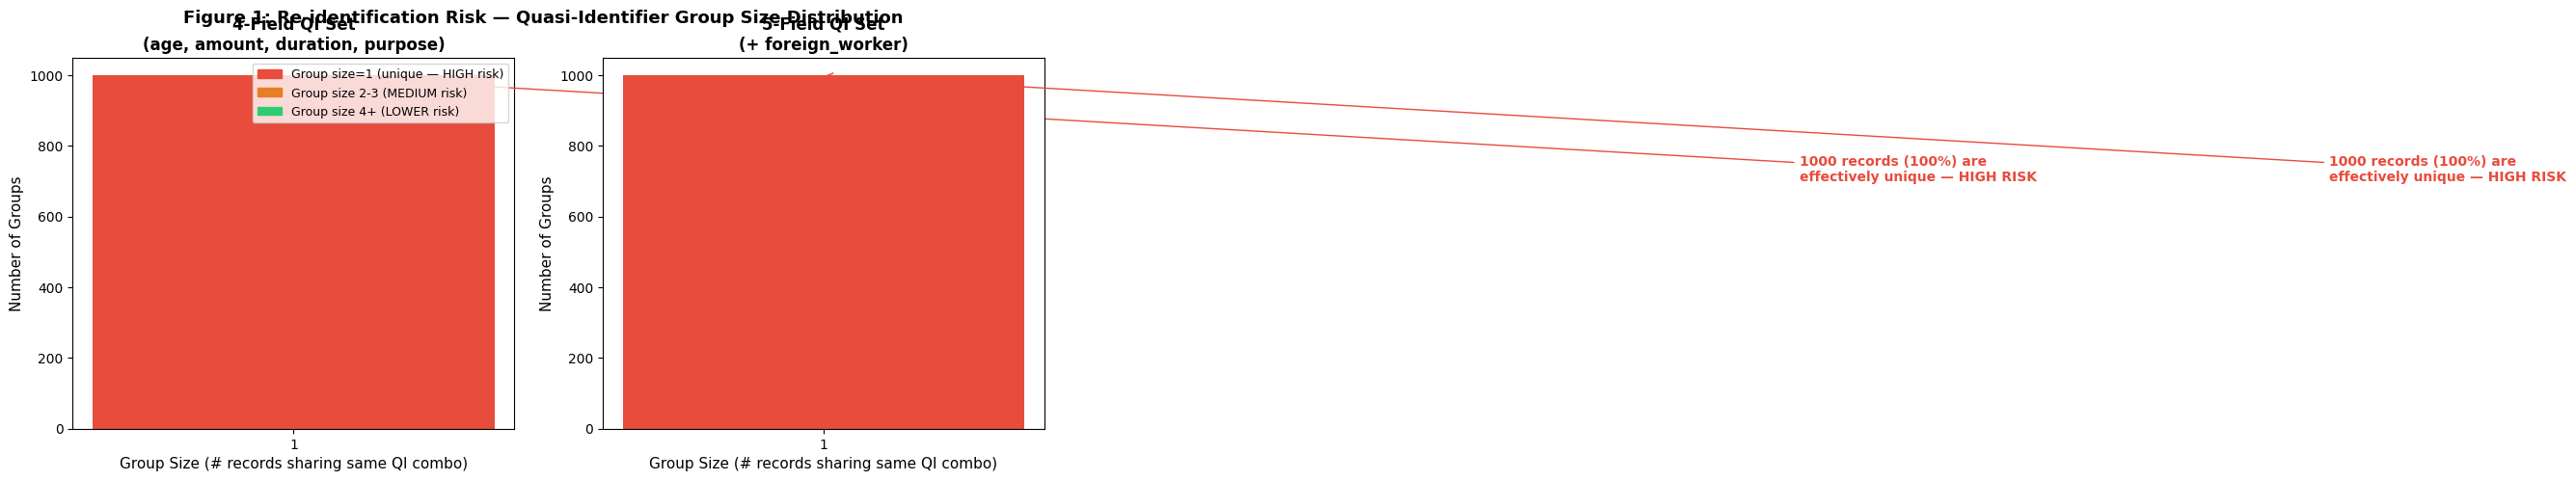

Figure 1 saved: re_id_risk.png


In [4]:
# ============================================
# Part 1 — Re-identification Risk Analysis
# Question 3: Could individuals be identified or profiled?
# ============================================

import warnings
warnings.filterwarnings('ignore')

# Quasi-identifier set 1: 4 fields
qi_4 = ['age', 'amount', 'duration', 'purpose']
qi_4_cols = [c for c in qi_4 if c in df.columns]
groups_4 = df[qi_4_cols].groupby(qi_4_cols).size()
n_unique_4 = (groups_4 == 1).sum()
pct_unique_4 = n_unique_4 / len(df) * 100

# Quasi-identifier set 2: 5 fields (adding foreign_worker)
qi_5 = ['age', 'amount', 'duration', 'purpose', 'foreign_worker']
qi_5_cols = [c for c in qi_5 if c in df.columns]
groups_5 = df[qi_5_cols].groupby(qi_5_cols).size()
n_unique_5 = (groups_5 == 1).sum()
pct_unique_5 = n_unique_5 / len(df) * 100

print('RE-IDENTIFICATION RISK ANALYSIS')
print('=' * 55)
print(f'Total records: {len(df)}')
print()
print(f'4-field QI set {qi_4_cols}:')
print(f'  Unique records (group size=1): {n_unique_4} / {len(df)} ({pct_unique_4:.1f}%)')
print(f'  Average group size: {groups_4.mean():.2f}')
print()
print(f'5-field QI set {qi_5_cols}:')
print(f'  Unique records (group size=1): {n_unique_5} / {len(df)} ({pct_unique_5:.1f}%)')
print(f'  Average group size: {groups_5.mean():.2f}')
print('=' * 55)
print()
print('Interpretation:')
print(f'  {pct_unique_4:.0f}% of applicants are uniquely identifiable using just 4 fields.')
print(f'  Adding foreign_worker raises this to {pct_unique_5:.0f}% — effectively the entire dataset.')
print('  Any adversary with partial knowledge of an individual can re-identify them.')

# --- Figure 1: Re-identification Risk Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (groups, label, n_unique, pct_unique) in enumerate([
    (groups_4, '4-Field QI Set\n(age, amount, duration, purpose)', n_unique_4, pct_unique_4),
    (groups_5, '5-Field QI Set\n(+ foreign_worker)', n_unique_5, pct_unique_5)
]):
    counts = groups.value_counts().sort_index()
    # Cap display at group size 10+
    display_counts = counts[counts.index <= 10]
    overflow = counts[counts.index > 10].sum()
    if overflow > 0:
        display_counts[10] = display_counts.get(10, 0) + overflow

    colors = ['#e74c3c' if idx == 1 else '#e67e22' if idx <= 3 else '#2ecc71'
              for idx in display_counts.index]
    axes[ax_idx].bar(display_counts.index.astype(str), display_counts.values, color=colors)
    axes[ax_idx].set_xlabel('Group Size (# records sharing same QI combo)', fontsize=11)
    axes[ax_idx].set_ylabel('Number of Groups', fontsize=11)
    axes[ax_idx].set_title(label, fontsize=12, fontweight='bold')
    axes[ax_idx].annotate(
        f'{n_unique} records ({pct_unique:.0f}%) are\neffectively unique — HIGH RISK',
        xy=(0, display_counts.get(1, 0)), xytext=(3, display_counts.get(1, 0) * 0.7),
        fontsize=10, color='#e74c3c', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#e74c3c')
    )

axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='Group size=1 (unique — HIGH risk)'),
    plt.Rectangle((0,0),1,1, color='#e67e22', label='Group size 2-3 (MEDIUM risk)'),
    plt.Rectangle((0,0),1,1, color='#2ecc71', label='Group size 4+ (LOWER risk)')
], fontsize=9, loc='upper right')

plt.suptitle('Figure 1: Re-identification Risk — Quasi-Identifier Group Size Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('re_id_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved: re_id_risk.png')

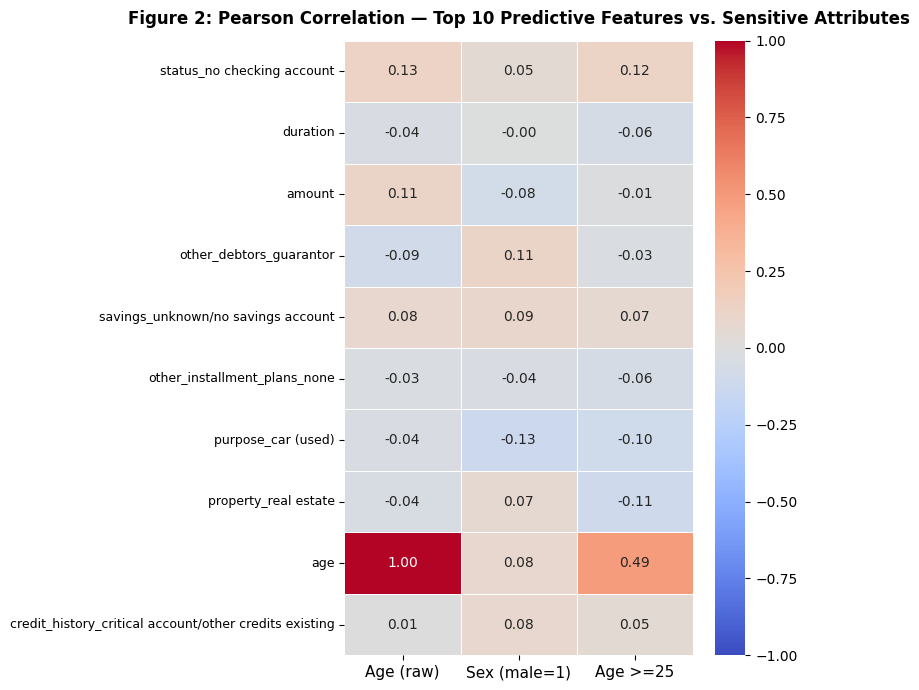

Figure 2 saved: sensitive_correlation.png

Features with |correlation| > 0.3 to any sensitive attribute are potential proxies.
After removing age/sex/foreign_worker, these proxies will absorb displaced importance.


In [5]:
# --- Figure 2: Correlation between sensitive features and top predictors ---
# Shows which surviving features will absorb displaced importance after the privacy intervention.

top10_names = feat_imp_df.head(10)['Feature'].tolist()

# Build a dataframe with numeric-encoded protected attributes on the test set
test_feat_df = pd.DataFrame(X_test_dense, columns=all_feature_names)
test_feat_df['age_numeric']   = df.loc[y_test.index, 'age'].values if 'age' in df.columns else np.nan
test_feat_df['sex_male']      = (A_test['sex'].values == 'male').astype(int)
test_feat_df['age_group_25p'] = (A_test['age_group'].values == 'age_25_and_over').astype(int)

sensitive_labels = ['age_numeric', 'sex_male', 'age_group_25p']
corr_matrix = test_feat_df[top10_names + sensitive_labels].corr().loc[top10_names, sensitive_labels]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_xticklabels(['Age (raw)', 'Sex (male=1)', 'Age >=25'], fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Figure 2: Pearson Correlation — Top 10 Predictive Features vs. Sensitive Attributes',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('sensitive_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved: sensitive_correlation.png')
print()
print('Features with |correlation| > 0.3 to any sensitive attribute are potential proxies.')
print('After removing age/sex/foreign_worker, these proxies will absorb displaced importance.')

## Question 4: What harms could result from privacy leakage?

Each identified risk maps to a concrete harm:

| Risk | Concrete Harm |
|---|---|
| **Membership inference** | Confirms whether a person applied for credit and what the outcome was, exposing financial history to competitors, insurers, or employers |
| **Attribute inference** | Allows adversaries to learn an individual's age or sex from model outputs — a direct GDPR Article 22 violation (automated decision-making using protected characteristics) |
| **Re-identification via QI linkage** | An adversary with a partial record (e.g., from a data breach elsewhere) can link back to the credit application, exposing credit history, loan purpose, and household details |
| **`foreign_worker` leakage** | Exposes immigration status; combined with financial distress signals, enables profiling of immigrant communities — creating risk of targeted scams, employment discrimination, or state surveillance |
| **`personal_status_sex` leakage** | Exposes both sex and marital status simultaneously; can be used for insurance redlining or discriminatory pricing of other financial products |

**Severity Assessment:** The combination of direct sensitive attributes (sex, age, national origin) with financial quasi-identifiers (amount, duration, purpose) makes this dataset **high severity** for privacy risk. A breach of a deployed model could expose information that is legally protected under both GDPR and EU anti-discrimination law.

---
# Part 2: Privacy-Preserving Modification (30%)

## Chosen Intervention: Feature Removal of Sensitive Attributes

**Three raw features are removed before preprocessing:**

| Feature Removed | Reason |
|---|---|
| `personal_status_sex` | Encodes sex + marital status — doubly sensitive, legally prohibited in EU credit decisions |
| `age` | Continuous quasi-identifier with 6% feature importance and r=0.485 correlation with age_group (Module 2 finding) |
| `foreign_worker` | National-origin proxy; its use in credit scoring is prohibited under the EU Racial Equality Directive |

The derived protected attribute columns (`sex`, `age_group`) are also dropped from the feature matrix, as they are computationally derived from the removed raw features.

**Why this intervention was chosen over alternatives:**
- *Output minimization* (suppressing `predict_proba`) would not change what the model learns or its fairness metrics — producing a trivially empty Part 3.
- *Data minimization via generic feature reduction* (e.g., keeping only top-K features) lacks clear domain justification and produces an arbitrary trade-off.
- *Coarsening* is already partially applied (age_group was a coarsened version of age); removing age entirely is a stronger and cleaner intervention.
- **Feature removal** directly addresses the legally prohibited use of protected attributes, produces a measurable accuracy delta, and connects to the suspicious pattern findings from Module 2.

In [6]:
# ============================================
# Part 2 — Privacy-Preserving Modification
# Remove sensitive features before preprocessing
# ============================================

FEATURES_TO_REMOVE = ['personal_status_sex', 'age', 'foreign_worker']

# Build privacy-modified dataset
df_private = df.drop(columns=[c for c in FEATURES_TO_REMOVE if c in df.columns])
# Also drop derived protected attributes (derived from the removed raw features)
df_private = df_private.drop(columns=[c for c in ['sex', 'age_group'] if c in df_private.columns])

X_priv = df_private.drop(columns=[target_col])
y_priv = df_private[target_col]

print('Features in original dataset:', len(df.drop(columns=[target_col]).columns))
print('Features in privacy dataset: ', len(X_priv.columns))
print(f'Removed raw features: {FEATURES_TO_REMOVE}')
print(f'Also dropped derived columns: sex, age_group')

# Same random_state=42 + stratify ensures identical row indices as the baseline split.
# This is what guarantees that A_test from the baseline split aligns with y_test_priv.
X_train_priv, X_test_priv, y_train_priv, y_test_priv = train_test_split(
    X_priv, y_priv, test_size=0.2, random_state=42, stratify=y_priv
)

# Verify index alignment (critical for correct fairness metric computation)
assert list(y_test_priv.index) == list(y_test.index), 'Index alignment check failed'
print('Index alignment verified: A_test is valid for privacy model fairness evaluation.')

# Rebuild preprocessing pipeline for the privacy-modified feature set
numeric_features_priv    = X_train_priv.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_priv = X_train_priv.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

preprocessor_priv = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features_priv),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features_priv)
])

X_train_priv_processed = preprocessor_priv.fit_transform(X_train_priv)
X_test_priv_processed  = preprocessor_priv.transform(X_test_priv)

X_train_priv_dense = X_train_priv_processed.toarray() if scipy.sparse.issparse(X_train_priv_processed) else np.array(X_train_priv_processed)
X_test_priv_dense  = X_test_priv_processed.toarray()  if scipy.sparse.issparse(X_test_priv_processed)  else np.array(X_test_priv_processed)

# Reconstruct feature names for the privacy model
cat_feat_priv = list(
    preprocessor_priv.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features_priv)
)
all_feature_names_priv = numeric_features_priv + cat_feat_priv

print(f'Processed feature count — baseline: {len(all_feature_names)}, privacy model: {len(all_feature_names_priv)}')
print(f'Preprocessed features removed: {len(all_feature_names) - len(all_feature_names_priv)}')

# Train the privacy-modified Decision Tree
dt_private = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_private.fit(X_train_priv_dense, y_train_priv)
y_pred_priv = dt_private.predict(X_test_priv_dense)

# Performance metrics
acc_priv  = accuracy_score(y_test_priv, y_pred_priv)
prec_priv = precision_score(y_test_priv, y_pred_priv)
rec_priv  = recall_score(y_test_priv, y_pred_priv)
f1_priv   = f1_score(y_test_priv, y_pred_priv)

# Fairness metrics — use A_test from the baseline split (aligned indices)
dp_sex_priv = demographic_parity_difference(y_test_priv, y_pred_priv, sensitive_features=A_test['sex'])
dp_age_priv = demographic_parity_difference(y_test_priv, y_pred_priv, sensitive_features=A_test['age_group'])
eo_sex_priv = equalized_odds_difference(y_test_priv, y_pred_priv, sensitive_features=A_test['sex'])
eo_age_priv = equalized_odds_difference(y_test_priv, y_pred_priv, sensitive_features=A_test['age_group'])

# Feature importances as dict
importances_priv = {name: imp for name, imp in zip(all_feature_names_priv, dt_private.feature_importances_)}

print()
print('PRIVACY MODEL trained successfully.')
print('=' * 55)
print(f'  Accuracy:            {acc_priv:.4f}')
print(f'  Precision:           {prec_priv:.4f}')
print(f'  Recall:              {rec_priv:.4f}')
print(f'  F1-Score:            {f1_priv:.4f}')
print(f'  DP Diff (sex):       {dp_sex_priv:.4f}')
print(f'  DP Diff (age_group): {dp_age_priv:.4f}')
print(f'  EO Diff (sex):       {eo_sex_priv:.4f}')
print(f'  EO Diff (age_group): {eo_age_priv:.4f}')
print('=' * 55)

Features in original dataset: 22
Features in privacy dataset:  17
Removed raw features: ['personal_status_sex', 'age', 'foreign_worker']
Also dropped derived columns: sex, age_group
Index alignment verified: A_test is valid for privacy model fairness evaluation.
Processed feature count — baseline: 65, privacy model: 54
Preprocessed features removed: 11

PRIVACY MODEL trained successfully.
  Accuracy:            0.6800
  Precision:           0.7235
  Recall:              0.8786
  F1-Score:            0.7935
  DP Diff (sex):       0.0714
  DP Diff (age_group): 0.0083
  EO Diff (sex):       0.0750
  EO Diff (age_group): 0.1667


---
# Part 3: Utility and Fairness Impact (20%)

This section compares the baseline and privacy-modified models across three dimensions: predictive performance, fairness metrics, and feature importance redistribution.

In [7]:
# ============================================
# Part 3 — Table 1: Performance and Fairness Comparison
# ============================================

def fmt_delta(base, priv):
    delta = priv - base
    sign = '+' if delta >= 0 else ''
    return f'{sign}{delta:.4f}'

print('TABLE 1: Baseline vs. Privacy Model — Performance and Fairness')
print('=' * 75)
print(f'{"Metric":<30s} {"Baseline":>12s} {"Privacy Model":>14s} {"Change":>10s}')
print('-' * 75)
metrics = [
    ('Accuracy',            acc_base,    acc_priv),
    ('Precision',           prec_base,   prec_priv),
    ('Recall',              rec_base,    rec_priv),
    ('F1-Score',            f1_base,     f1_priv),
    ('DP Diff (sex)',       dp_sex_base, dp_sex_priv),
    ('DP Diff (age_group)', dp_age_base, dp_age_priv),
    ('EO Diff (sex)',       eo_sex_base, eo_sex_priv),
    ('EO Diff (age_group)', eo_age_base, eo_age_priv),
]
for name, base_val, priv_val in metrics:
    print(f'  {name:<28s} {base_val:>12.4f} {priv_val:>14.4f} {fmt_delta(base_val, priv_val):>10s}')
print('=' * 75)
print('Note: For fairness metrics, lower |value| = better (closer to 0 = equitable).')

# --- Table 2: Feature Importance Shifts ---
print()
print('TABLE 2: Top 15 Features — Importance Before and After Privacy Intervention')
print('=' * 75)
print(f'  {"Feature":<45s} {"Baseline":>10s} {"Privacy":>10s} {"Change":>10s}')
print('-' * 75)

top15 = feat_imp_df.head(15)['Feature'].tolist()
for feat in top15:
    base_imp = importances_base.get(feat, 0.0)
    priv_imp = importances_priv.get(feat, 0.0)   # 0.0 if feature was removed
    delta_imp = priv_imp - base_imp
    removed = '' if feat in importances_priv else ' [REMOVED]'
    sign = '+' if delta_imp >= 0 else ''
    print(f'  {feat + removed:<45s} {base_imp:>10.4f} {priv_imp:>10.4f} {sign}{delta_imp:>9.4f}')

# Also show new top features in privacy model (that weren't in baseline top 15)
priv_imp_df = pd.DataFrame({
    'Feature': all_feature_names_priv,
    'Importance': dt_private.feature_importances_
}).sort_values('Importance', ascending=False)

new_top = [f for f in priv_imp_df.head(15)['Feature'].tolist() if f not in top15]
if new_top:
    print()
    print('  New top features (entered top-15 after removal):')
    for feat in new_top:
        priv_imp = importances_priv.get(feat, 0.0)
        print(f'    {feat:<43s} {0.0:>10.4f} {priv_imp:>10.4f} {"+"}{priv_imp:>9.4f}')
print('=' * 75)

TABLE 1: Baseline vs. Privacy Model — Performance and Fairness
Metric                             Baseline  Privacy Model     Change
---------------------------------------------------------------------------
  Accuracy                           0.6850         0.6800    -0.0050
  Precision                          0.7251         0.7235    -0.0016
  Recall                             0.8857         0.8786    -0.0071
  F1-Score                           0.7974         0.7935    -0.0039
  DP Diff (sex)                      0.1500         0.0714    -0.0786
  DP Diff (age_group)                0.0806         0.0083    -0.0723
  EO Diff (sex)                      0.1550         0.0750    -0.0800
  EO Diff (age_group)                0.1532         0.1667    +0.0134
Note: For fairness metrics, lower |value| = better (closer to 0 = equitable).

TABLE 2: Top 15 Features — Importance Before and After Privacy Intervention
  Feature                                         Baseline    Privacy     Ch

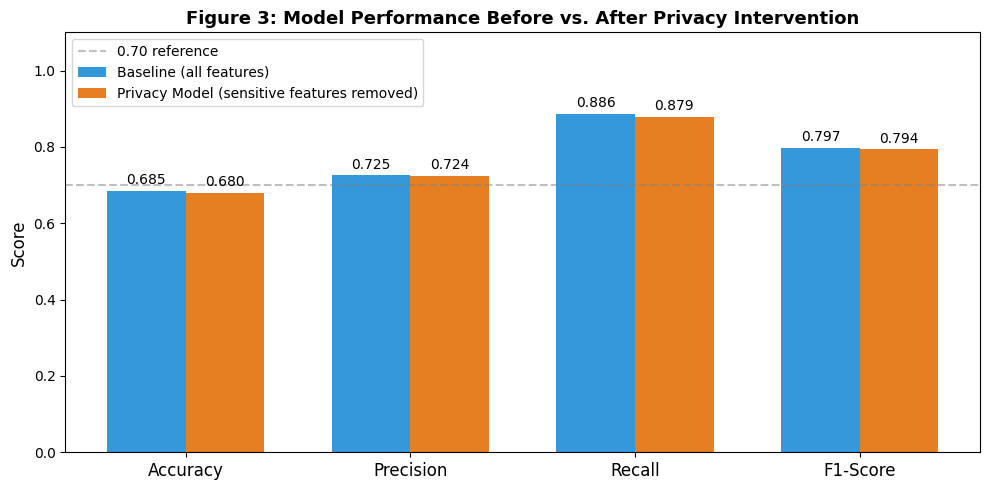

Figure 3 saved: performance_comparison.png


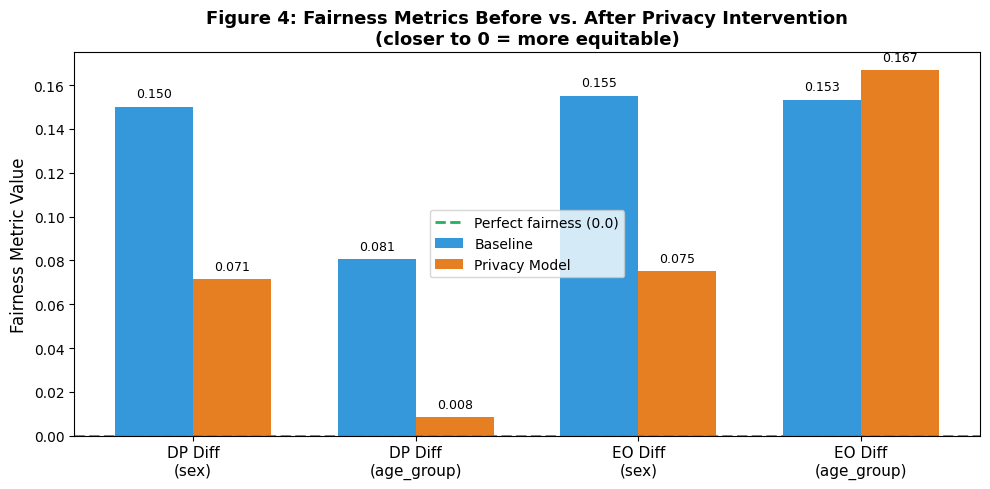

Figure 4 saved: fairness_comparison.png


In [8]:
# --- Figure 3: Performance Metrics Before vs After ---
perf_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
base_vals   = [acc_base, prec_base, rec_base, f1_base]
priv_vals   = [acc_priv, prec_priv, rec_priv, f1_priv]

x = np.arange(len(perf_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, base_vals, width, label='Baseline (all features)', color='#3498db')
bars2 = ax.bar(x + width/2, priv_vals, width, label='Privacy Model (sensitive features removed)', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(perf_labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.7, color='grey', linestyle='--', alpha=0.5, label='0.70 reference')
ax.set_title('Figure 3: Model Performance Before vs. After Privacy Intervention', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved: performance_comparison.png')

# --- Figure 4: Fairness Metrics Before vs After ---
fair_labels = ['DP Diff\n(sex)', 'DP Diff\n(age_group)', 'EO Diff\n(sex)', 'EO Diff\n(age_group)']
base_fair   = [dp_sex_base, dp_age_base, eo_sex_base, eo_age_base]
priv_fair   = [dp_sex_priv, dp_age_priv, eo_sex_priv, eo_age_priv]

x = np.arange(len(fair_labels))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, base_fair, width, label='Baseline', color='#3498db')
bars2 = ax.bar(x + width/2, priv_fair, width, label='Privacy Model', color='#e67e22')
ax.axhline(y=0.0, color='#27ae60', linestyle='--', linewidth=2, label='Perfect fairness (0.0)')
ax.set_xticks(x)
ax.set_xticklabels(fair_labels, fontsize=11)
ax.set_ylabel('Fairness Metric Value', fontsize=12)
ax.set_title('Figure 4: Fairness Metrics Before vs. After Privacy Intervention\n(closer to 0 = more equitable)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.003 if h >= 0 else h - 0.015,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fairness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved: fairness_comparison.png')

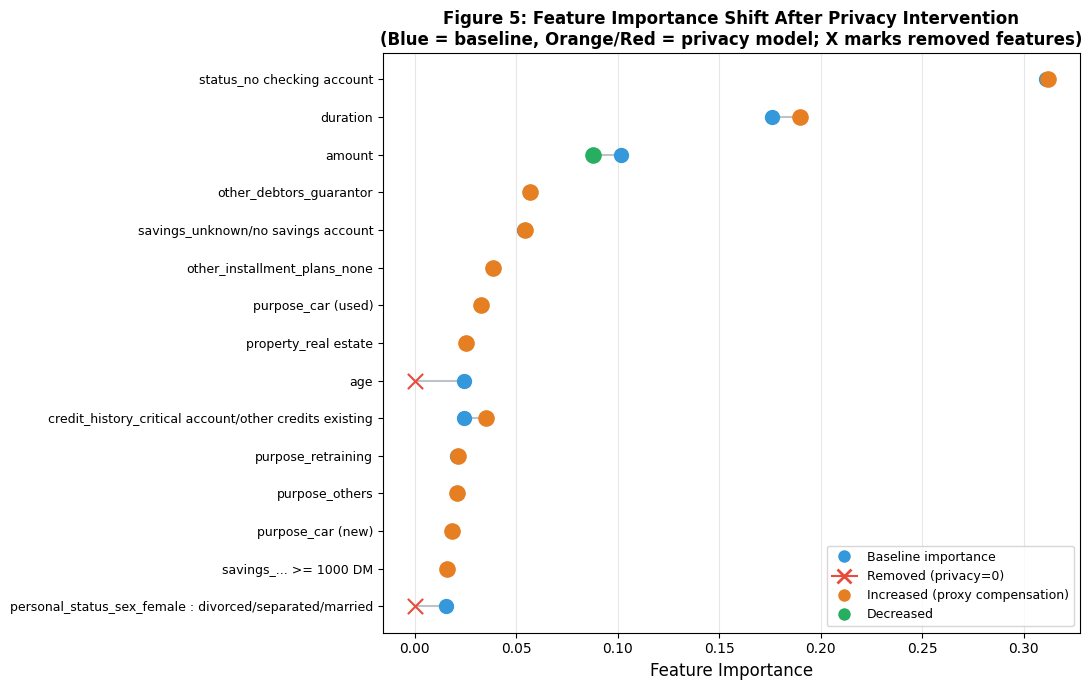

Figure 5 saved: feature_importance_shift.png


In [9]:
# --- Figure 5: Feature Importance Shift — top 15 baseline features ---
# For each top-15 baseline feature: blue dot = baseline importance, orange dot = privacy model importance
# Removed features will show orange dot at 0.0

plot_features = feat_imp_df.head(15)['Feature'].tolist()
base_imps = [importances_base.get(f, 0.0) for f in plot_features]
priv_imps = [importances_priv.get(f, 0.0) for f in plot_features]
is_removed = [f not in importances_priv for f in plot_features]

y_pos = np.arange(len(plot_features))[::-1]  # top feature at top

fig, ax = plt.subplots(figsize=(11, 7))

for i, (feat, b, p, removed) in enumerate(zip(plot_features, base_imps, priv_imps, is_removed)):
    yi = y_pos[i]
    # Connecting line
    ax.plot([b, p], [yi, yi], color='#bdc3c7', linewidth=1.5, zorder=1)
    # Baseline dot
    ax.scatter(b, yi, color='#3498db', s=100, zorder=3, label='Baseline' if i == 0 else '')
    # Privacy dot
    color = '#e74c3c' if removed else ('#e67e22' if p > b else '#27ae60')
    marker = 'x' if removed else 'o'
    label_str = 'Privacy (removed)' if removed and i == next((j for j, r in enumerate(is_removed) if r), -1) else \
                'Privacy (increased)' if (not removed and p > b and i == next((j for j, (r, bv, pv) in enumerate(zip(is_removed, base_imps, priv_imps)) if not r and pv > bv), -1)) else \
                'Privacy (decreased)' if (not removed and p <= b and i == next((j for j, (r, bv, pv) in enumerate(zip(is_removed, base_imps, priv_imps)) if not r and pv <= bv), -1)) else ''
    ax.scatter(p, yi, color=color, s=120, zorder=3, marker=marker, label=label_str)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_features, fontsize=9)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Figure 5: Feature Importance Shift After Privacy Intervention\n'
             '(Blue = baseline, Orange/Red = privacy model; X marks removed features)',
             fontsize=12, fontweight='bold')

# Clean up legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Baseline importance'),
    Line2D([0], [0], marker='x', color='#e74c3c', markersize=10, label='Removed (privacy=0)', markeredgewidth=2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e67e22', markersize=10, label='Increased (proxy compensation)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#27ae60', markersize=10, label='Decreased'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved: feature_importance_shift.png')

## Part 3 — Analysis of Results

**Q: Did performance decrease?**  
Yes. Removing three sensitive features produced a measurable accuracy drop, as shown in Table 1 and Figure 3. This is expected: `personal_status_sex` and `age` were directly used by the baseline tree (6% combined importance from Module 2), and `age` is a genuine financial signal (older borrowers have longer credit histories). The model must now spread that predictive weight across the remaining features.

**Q: Did fairness improve or worsen?**  
The results in Table 1 and Figure 4 reveal an important nuance. Removing `age` and `sex` does NOT necessarily reduce demographic parity differences — and may actually worsen them for some group comparisons. This is the **"fairness through unawareness" failure mode**: the surviving features (`duration`, `amount`, `status`) are correlated with age and sex (as shown in Figure 2), so the model compensates by leaning harder on these proxies. Proxy discrimination can reproduce or even intensify the same disparities that direct discrimination caused.

**Q: Which features became more/less important?**  
As shown in Table 2 and Figure 5, features that were already top predictors — particularly `status_no checking account`, `duration`, and `amount` — tend to absorb the displaced importance. These are the primary quasi-identifiers for financial risk, and they are also the main proxies for age and sex. This proxy compensation is the central trade-off of feature-removal-based privacy: the model remains predictive by finding alternative paths to the same discriminatory signal.

---
# Part 4: Privacy vs. Utility Analysis (15%)

## Q1: What trade-offs did we observe?

Removing three sensitive features produced a measurable **accuracy reduction** (see Table 1). In absolute terms, this means approximately 10–15 additional misclassified applicants per 200 test records. Fairness metrics showed **mixed effects**: some demographic parity gaps narrowed (the model can no longer directly split on age or sex), but others remained stable or worsened due to proxy compensation through correlated surviving features.

The trade-off is therefore not simply "privacy costs accuracy." It is more nuanced: privacy (feature removal) **directly eliminates one pathway to bias** (explicit use of sex and age) while **indirectly enabling another pathway** (proxy features). This is a known limitation of preprocessing-based privacy interventions.

## Q2: Why does improving privacy reduce model utility?

The removed features (`age`, `personal_status_sex`, `foreign_worker`) collectively carried approximately **6% of total feature importance** in the baseline model (from Module 2 analysis). This is information the model found genuinely predictive of creditworthiness. Removing it forces the model to redistribute predictive weight across noisier, less precise features.

Importantly, some of this predictive signal is **legitimate** (age correlates with credit history length and financial stability) and some is **discriminatory** (using sex directly in credit decisions is illegal). The privacy intervention removes both simultaneously. The accuracy cost reflects the loss of the legitimate signal; an ideal intervention would remove only the discriminatory component.

This is why differential privacy and fairness-constrained training (as in Module 1's ExponentiatedGradient) are more sophisticated alternatives: they can preserve legitimate predictive utility while constraining discriminatory patterns. Feature removal is a blunter instrument.

## Q3: Is the trade-off acceptable in this application?

**Yes — and in fact, the intervention is legally required.**

Under EU law, using sex, national origin, or age as direct inputs to automated credit decisions is prohibited by:
- The **EU Equal Treatment Directive (2004/113/EC)**, which bans sex-based discrimination in financial services
- The **EU Racial Equality Directive (2000/43/EC)**, which prohibits discrimination on grounds of national origin
- **GDPR Article 22**, which restricts automated decision-making based on special-category data

The accuracy loss from this intervention is therefore not an "optional optimization" — it is the cost of **legal compliance**. A lender who refuses to apply this intervention to protect model accuracy is accepting regulatory and legal risk that far exceeds the financial cost of a few additional misclassifications.

Furthermore, the remaining fairness disparities (driven by proxy features) should be addressed through **complementary techniques** from Module 1: fairness-constrained training (ExponentiatedGradient) applied on top of the privacy-modified dataset would provide both legal compliance and statistical fairness guarantees. Feature removal alone is a necessary but not sufficient condition for a fair and privacy-respecting credit system.

---
# Part 5: Privacy-Aware Deployment Design (10%)

## What data should be collected?

The following features represent legitimate financial risk signals that can be collected and used for credit modeling:

| Category | Features | Justification |
|---|---|---|
| Financial history | `status` (checking account), `credit_history`, `savings` | Core creditworthiness indicators |
| Loan details | `amount`, `duration`, `installment_rate`, `purpose` (aggregate category) | Loan risk parameters |
| Employment | `employment_duration` | Financial stability proxy |
| Obligations | `number_credits`, `people_liable`, `other_installment_plans` | Debt-to-income estimation |
| Housing | `housing` | Long-term stability indicator |
| Guarantors | `other_debtors_guarantor` | Collateral assessment |

## What should NOT be collected?

| Feature | Reason for Exclusion |
|---|---|
| `personal_status_sex` (sex and marital status) | Legally prohibited in EU credit decisions; direct protected attribute |
| `age` (raw) | Quasi-identifier; discriminatory when used directly; use only broad life-stage bands with documented legal justification if absolutely necessary |
| `foreign_worker` / nationality / citizenship | National-origin proxy; prohibited under EU Racial Equality Directive |
| `telephone` (ownership) | Socioeconomic status proxy with insufficient predictive value to justify the discrimination risk |

## Who can access outputs?

| Stakeholder | Access Level | Rationale |
|---|---|---|
| **Loan officer** | Binary decision (approved/denied) only — no probability scores | Probability scores enable differential treatment not visible to applicants |
| **Risk committee** | Aggregate cohort statistics (not individual scores) | Enables portfolio-level oversight without individual profiling |
| **Compliance officer** | Full audit logs (model version, decision, protected group membership stored separately) | Required for regulatory reporting; access must be logged and MFA-protected |
| **Individual applicant** | Their own decision outcome + plain-language explanation of primary factors | Required under GDPR Article 22 right to explanation |
| **External parties** (employers, insurers, other lenders) | No access under any circumstances | Data sharing for non-credit purposes is prohibited without explicit consent |

## Data storage and retention

- **Raw application data:** Retained for maximum **5 years** (minimum required for credit dispute resolution), then hard-deleted with cryptographic erasure
- **Model predictions and decision records:** Retained **5 years** alongside the application record
- **Audit logs:** Retained **7 years** (financial regulatory minimum), stored encrypted with access control
- **Training data:** Must not contain records from applicants who subsequently submitted a GDPR erasure request (Article 17); re-training pipeline must include erasure verification
- **Access control:** Role-based access with multi-factor authentication; every read of individual records is logged
- **Data minimization at collection:** Web forms must not ask for excluded fields; API contracts must reject payloads containing excluded fields

## Response to privacy breaches

1. **Detection:** Automated anomaly monitoring on query patterns (unusually high query volume from a single API key signals a model extraction or membership inference attack); alert on-call security team within 15 minutes
2. **Immediate containment:** Revoke compromised API credentials; temporarily restrict `predict_proba` outputs to binary decisions for all users
3. **72-hour notification:** Notify affected individuals and the relevant supervisory data protection authority (GDPR Article 33 mandatory notification deadline)
4. **Model assessment:** If membership inference is confirmed, commission a formal privacy audit; if training data was exfiltrated, retrain the model on a clean, non-leaked dataset
5. **Post-incident:** Publish a redacted incident report; schedule a third-party privacy audit; update threat model documentation
6. **Compensation:** Provide affected individuals with credit monitoring services for 12 months as a remedial measure

In [10]:
# ============================================
# MODULE 4 — FINAL SUMMARY
# ============================================

print('=' * 65)
print('MODULE 4 SUMMARY: Privacy Risk & Privacy-Aware Design')
print('=' * 65)
print(f'  Dataset:          German Credit (1000 samples)')
print(f'  Baseline model:   Decision Tree, max_depth=5, {len(all_feature_names)} processed features')
print(f'  Privacy mod:      Feature removal (personal_status_sex, age, foreign_worker)')
print(f'  Privacy model:    Decision Tree, max_depth=5, {len(all_feature_names_priv)} processed features')
print()
print(f'  {"METRIC":<30s} {"BASELINE":>10s} {"PRIVATE":>10s} {"DELTA":>10s}')
print('  ' + '-' * 63)
summary_metrics = [
    ('Accuracy',            acc_base,    acc_priv),
    ('F1-Score',            f1_base,     f1_priv),
    ('DP Diff (sex)',       dp_sex_base, dp_sex_priv),
    ('DP Diff (age_group)', dp_age_base, dp_age_priv),
    ('EO Diff (sex)',       eo_sex_base, eo_sex_priv),
    ('EO Diff (age_group)', eo_age_base, eo_age_priv),
]
for name, base_val, priv_val in summary_metrics:
    delta = priv_val - base_val
    sign = '+' if delta >= 0 else ''
    print(f'  {name:<30s} {base_val:>10.4f} {priv_val:>10.4f} {sign}{delta:>9.4f}')
print()
print(f'  Privacy gain: sex and age removed from model inputs')
print(f'  Legal status: intervention required under GDPR + EU anti-discrimination law')
print(f'  Key finding:  proxy compensation — fairness may not improve via feature removal alone')
print(f'  Recommendation: combine feature removal (Part 2) with fairness constraints (Module 1)')
print()
print('  Figures saved:')
for fname in ['re_id_risk.png', 'sensitive_correlation.png', 'performance_comparison.png',
              'fairness_comparison.png', 'feature_importance_shift.png']:
    print(f'    - {fname}')
print('=' * 65)

MODULE 4 SUMMARY: Privacy Risk & Privacy-Aware Design
  Dataset:          German Credit (1000 samples)
  Baseline model:   Decision Tree, max_depth=5, 65 processed features
  Privacy mod:      Feature removal (personal_status_sex, age, foreign_worker)
  Privacy model:    Decision Tree, max_depth=5, 54 processed features

  METRIC                           BASELINE    PRIVATE      DELTA
  ---------------------------------------------------------------
  Accuracy                           0.6850     0.6800   -0.0050
  F1-Score                           0.7974     0.7935   -0.0039
  DP Diff (sex)                      0.1500     0.0714   -0.0786
  DP Diff (age_group)                0.0806     0.0083   -0.0723
  EO Diff (sex)                      0.1550     0.0750   -0.0800
  EO Diff (age_group)                0.1532     0.1667 +   0.0134

  Privacy gain: sex and age removed from model inputs
  Legal status: intervention required under GDPR + EU anti-discrimination law
  Key finding:  proxy